In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
N = 1000
mu=0.1
#this is a package that converts the following function to machine code before running it.
#this is not strictly necessary, but without it running all the simulations takes about 40 minutes.
@jit(nopython=True)
def run_simulation(R0,max_t):
    t = 0
    beta= R0 * mu / N
    I = 1
    S = N - I
    while not (I <= 0 or t > max_t):
        r1 = np.random.random()
        r2 = np.random.random()
        totalRate = beta*I*S + mu*I
        t = t - (1/totalRate)*np.log(r1)
        if r2 < beta*I*S/totalRate:
            S = S - 1
            I = I + 1
        else:
            I = I - 1
            S = S + 1
    return t


In [26]:
def get_graph(R0,col):
    max_t = 4000
    n_sims = 10000
    t_values = []
    for i in range(n_sims):
        t = run_simulation(R0,max_t)
        t_values.append(t)
    probs = np.array([])
    times = np.array([])
    points = np.logspace(np.log10(1), np.log10(max_t), 1000)
    for i in range(1000):
        n = 0
        for j in range(n_sims):
            if t_values[j] >= points[i]:
                n += 1
        n /= n_sims
        probs = np.append(probs,n)
    if R0 > 1:
        plt.axhline(y=1-(1/R0),linestyle="--",color=col)
    plt.semilogx(points,probs,color=col,label=f"R0 = {R0}")

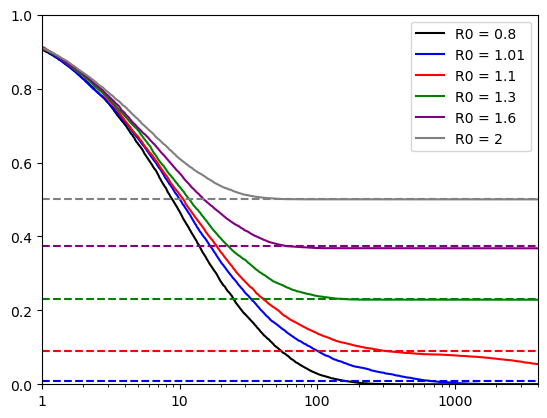

In [27]:
plt.ylim(0,1)
plt.xlim(1,4000)
get_graph(0.8,'black')
get_graph(1.01,'blue')
get_graph(1.1,'red')
get_graph(1.3,'green')
get_graph(1.6,'purple')
get_graph(2,'grey')

#makes x axis display 1,10,100 etc. instead of 10^0, 10^1, 10^2 etc.
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())

plt.legend()
plt.show()